# Exploration et Nettoyage des Données DVF (Île-de-France)

L'objectif de ce notebook est de transformer un fichier fiscal brut (DVF) en un dataset de Machine Learning qualitatif pour l'estimation immobilière. 

Le fichier DVF contient de nombreuses "scories" (erreurs de saisie, ventes de dépendances, rachats de parts) qui ne reflètent pas le marché immobilier standard. Chaque étape de nettoyage sera justifiée visuellement et par des règles métiers strictes.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration visuelle pour les graphiques 
sns.set_theme(style="whitegrid")

# Chargement optimisé (on ne prend que les colonnes utiles pour limiter l'utilisation de la RAM)
path_2024 = "../data/ValeursFoncieres-2024.txt"
cols_to_keep = [
    'Date mutation', 'Nature mutation', 'Valeur fonciere', 
    'Code postal', 'Code departement', 'Type local', 
    'Surface reelle bati', 'Nombre pieces principales', 'Surface terrain'
]

df = pd.read_csv(path_2024, sep="|", usecols=cols_to_keep, low_memory=False, dtype={'Code departement': str})
print(f"Volume initial : {len(df)} lignes.")

Volume initial : 3499931 lignes.


## 1. Définition du Périmètre d'Étude

Avant même de regarder les prix, nous devons nous assurer que nous ne comparons que des biens comparables. 
* **Le filtre Géographique** : Nous limitons à l'Île-de-France (IdF) pour avoir un marché tendu et cohérent.
* **Le filtre de Vente** : On exclut les "Echanges" ou "Adjudications" (enchères) qui ont des logiques de prix décotés.
* **Le filtre de Type de local** : On exclut les "Locaux industriels" et les "Dépendances" (garages, caves). Mélanger le prix d'un garage de 15m² avec une chambre de 15m² détruirait notre modèle.

In [16]:
# Filtre Géographique (IdF)
idf_depts = ['75', '77', '78', '91', '92', '93', '94', '95']
df = df[df['Code departement'].isin(idf_depts)]

# Filtre de transaction et de type
df = df[df['Nature mutation'] == 'Vente']
df = df[df['Type local'].isin(['Maison', 'Appartement'])]

# Nettoyage des types de données pour la suite
df['Valeur fonciere'] = df['Valeur fonciere'].astype(str).str.replace(',', '.').astype(float)
df['Surface terrain'] = df['Surface terrain'].fillna(0)

# Création de la variable cible : Le Prix au m²
df = df.dropna(subset=['Valeur fonciere', 'Surface reelle bati'])
df = df[df['Surface reelle bati'] > 0]
df['prix_m2'] = df['Valeur fonciere'] / df['Surface reelle bati']

print(f"Volume après périmètre de base : {len(df)} lignes.")

Volume après périmètre de base : 146695 lignes.


## 2. Analyse des Valeurs Aberrantes (Outliers)

Regardons la distribution des prix au m².

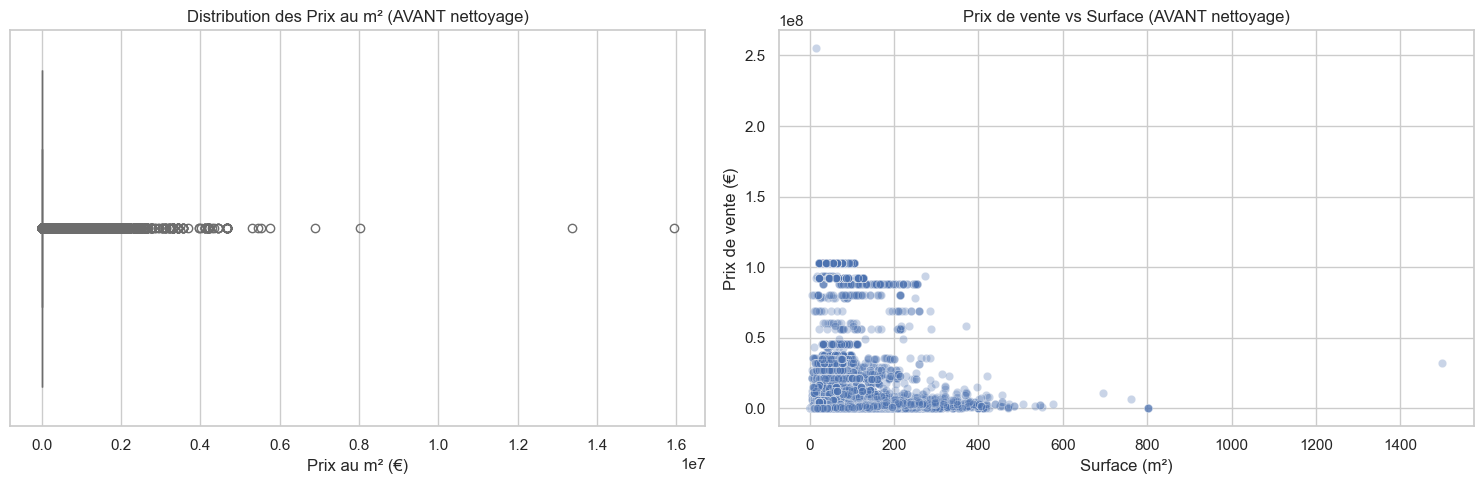

Prix au m² maximum enregistré : 15937500.00 €
Surface maximum enregistrée : 1500.0 m²


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graphique 1 : Boxplot global des prix
sns.boxplot(x=df['prix_m2'], ax=ax1, color='salmon')
ax1.set_title("Distribution des Prix au m² (AVANT nettoyage)")
ax1.set_xlabel("Prix au m² (€)")

# Graphique 2 : Zoom sur les surfaces
sns.scatterplot(data=df, x='Surface reelle bati', y='Valeur fonciere', ax=ax2, alpha=0.3)
ax2.set_title("Prix de vente vs Surface (AVANT nettoyage)")
ax2.set_xlabel("Surface (m²)")
ax2.set_ylabel("Prix de vente (€)")

plt.tight_layout()
plt.show()

*Si vous exécutez la cellule ci-dessus, vous verrez des prix au m² écrasés sur le graphique, montant parfois à plusieurs millions d'euros le m², ou des surfaces de 1500 m². C'est impossible pour un appartement.*

Nous devons appliquer des **Filtres Métiers** (basés sur la loi et la réalité du marché immobilier) plutôt que de simples filtres statistiques, car le marché immobilier parisien est naturellement biaisé vers les hauts prix.

### Justification des Seuils choisis :

1. **Surface Bâtie : [ 9 m² à 300 m² ]**
   * **Seuil bas (9 m²) :** Décret n°2002-120 (Loi Carrez / Critère de décence). Un logement ne peut légalement être loué/vendu comme habitation principale s'il fait moins de 9m². En dessous, c'est souvent une chambre de bonne non aménagée ou une erreur cadastrale.
   * **Seuil haut (300 m²) :** Au-delà de 300m², on entre dans le marché de l'hyper-luxe (hôtels particuliers, châteaux). L'objectif du modèle est d'estimer des biens standards pour le grand public. L'IA ne doit pas être perturbée par des châteaux.

2. **Prix au m² : [ 1 000 € à 31 000 € ]**
   * **Seuil bas (1 000 €) :** En Île-de-France, aucun logement habitable ne se vend sous 1 000 € / m². Les valeurs inférieures correspondent à des *ventes intrafamiliales* (prix cassé pour éviter les impôts), des *ventes en viager* (le prix affiché n'est que le bouquet), ou des biens en état de ruine totale.
   * **Seuil haut (31 000 €) :** Les prix les plus chers de Paris (Triangle d'Or, vue Tour Eiffel) plafonnent historiquement autour de 25 000 - 30 000 € / m². Un bien affiché à 100 000 € / m² dans le DVF est presque toujours une erreur du notaire (ex: vente d'un immeuble entier rattachée à la surface d'un seul appartement).

3. **Nombre de pièces : [ 1 à 10 ]**
   * Un appartement ne peut pas avoir 0 pièce (c'est souvent un garage mal catégorisé par le fisc). Plus de 10 pièces, on sort du cadre résidentiel classique.

In [18]:
# Filtre des surfaces (Loi de décence et exclusion des châteaux)
df_clean = df[(df['Surface reelle bati'] >= 9) & (df['Surface reelle bati'] <= 300)]

# Filtre des prix au m² (Exclusion viager/dons et erreurs de saisie hyper-luxe)
df_clean = df_clean[(df_clean['prix_m2'] >= 1000) & (df_clean['prix_m2'] <= 31000)]

# Filtre du nombre de pièces
df_clean = df_clean[(df_clean['Nombre pieces principales'] >= 1) & (df_clean['Nombre pieces principales'] <= 10)]

print(f"Lignes supprimées car aberrantes : {len(df) - len(df_clean)}")
print(f"Dataset final prêt pour le Machine Learning : {len(df_clean)} transactions.")

Lignes supprimées car aberrantes : 21888
Dataset final prêt pour le Machine Learning : 124807 transactions.


## 3. Visualisation Post-Nettoyage

Vérifions maintenant si notre dataset a une "allure" normale et exploitable pour un modèle prédictif. Nous devrions observer une belle courbe montrant la diversité du marché francilien.

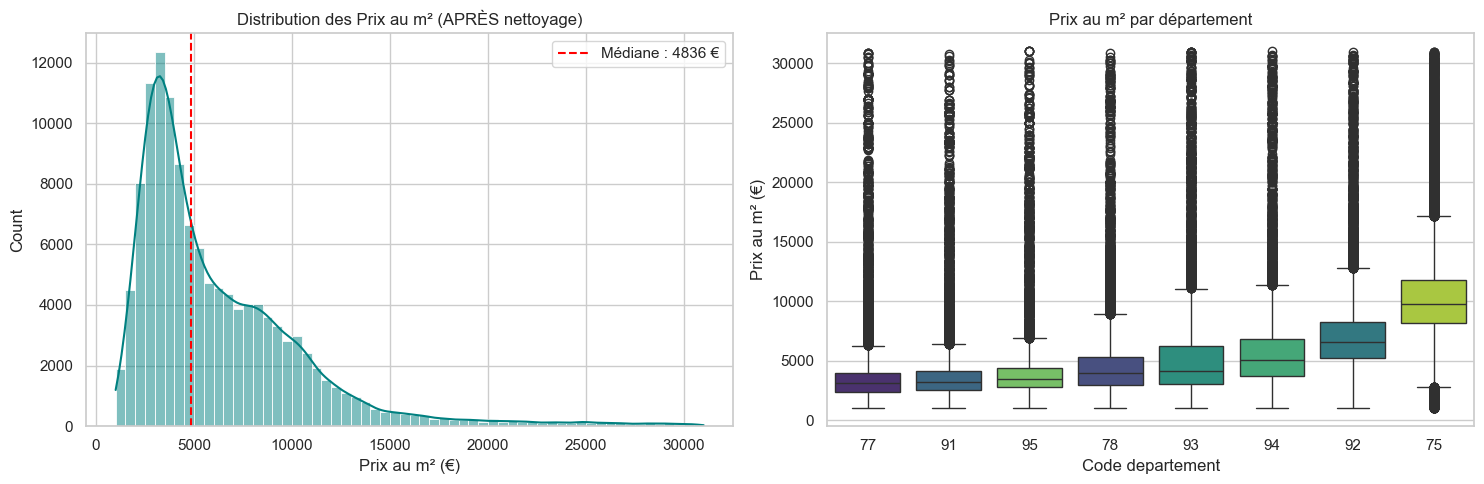

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graphique 1 : Histogramme de la distribution des prix
sns.histplot(df_clean['prix_m2'], bins=60, kde=True, ax=ax1, color='teal')
ax1.set_title("Distribution des Prix au m² (APRÈS nettoyage)")
ax1.set_xlabel("Prix au m² (€)")
ax1.axvline(df_clean['prix_m2'].median(), color='red', linestyle='--', label=f"Médiane : {df_clean['prix_m2'].median():.0f} €")
ax1.legend()

# Graphique 2 : Boxplot par département pour prouver la cohérence
order = df_clean.groupby('Code departement')['prix_m2'].median().sort_values().index
sns.boxplot(data=df_clean, x='Code departement', y='prix_m2', order=order, ax=ax2, hue='Code departement', palette="viridis", legend=False)
ax2.set_title("Prix au m² par département")
ax2.set_ylabel("Prix au m² (€)")

plt.tight_layout()
plt.show()